<a href="https://colab.research.google.com/github/jorgecedraz/PPEC0039---ESTATISTICA/blob/main/AMOSTRAGEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Amostragem Aleatória Simples

O código a seguir executa a Amostragem Aleatória Simples para a seleção imparcial dos corpos de prova do clínquer de cimento sulfoaluminato de cálcio belítico (CSAB). A partir de uma população física de 12 amostras cúbicas de argamassa (5x5x5 cm) pertencentes a um mesmo traço, o algoritmo realiza o sorteio automatizado de 3 unidades que serão destinadas ao ensaio de resistência à compressão aos 7 dias. Esta abordagem computacional substitui a seleção manual, garantindo total rigor estatístico e reprodutibilidade científica aos resultados mecânicos da pesquisa.




In [28]:
import pandas as pd
import numpy as np

# 1. CONSTRUÇÃO DO BANCO DE DADOS DA POPULAÇÃO (TRAÇO ÚNICO)
# Simulação dos 12 corpos de prova baseados nos parâmetros reais da pesquisa do CSAB.
# A massa simulada reflete o peso padrão de corpos de prova cúbicos de argamassa (5x5x5 cm).
# O total de 12 unidades atende perfeitamente aos ensaios em 4 idades de controle normativas
# (1, 3, 7 e 28 dias), garantindo 3 repetições por idade.

dados_csab = {
    'ID_Corpo_Prova': [f'CP_{i:02d}' for i in range(1, 13)],
    'Traco_Estequiometrico': ['Traço_Referência'] * 12, # Identificador do traço único
    'Massa_g': np.random.uniform(270.0, 285.0, 12).round(2),
}

# Consolidação dos dados em um DataFrame
df_populacao_csab = pd.DataFrame(dados_csab)

print("--- Panorama da População Total de Corpos de Prova (Traço Único) ---")
print(df_populacao_csab)
print("\n")

# 2. APLICAÇÃO DA AMOSTRAGEM ALEATÓRIA SIMPLES
# Extração não tendenciosa de 3 amostras para o ensaio de resistência à compressão aos 7 dias.
df_amostra_7dias = df_populacao_csab.sample(n=3)

--- Panorama da População Total de Corpos de Prova (Traço Único) ---
   ID_Corpo_Prova Traco_Estequiometrico  Massa_g
0           CP_01      Traço_Referência   281.78
1           CP_02      Traço_Referência   278.00
2           CP_03      Traço_Referência   276.76
3           CP_04      Traço_Referência   279.53
4           CP_05      Traço_Referência   273.54
5           CP_06      Traço_Referência   272.07
6           CP_07      Traço_Referência   283.16
7           CP_08      Traço_Referência   283.22
8           CP_09      Traço_Referência   281.36
9           CP_10      Traço_Referência   279.67
10          CP_11      Traço_Referência   279.75
11          CP_12      Traço_Referência   278.73




In [29]:
# 3. VALIDAÇÃO DOS DADOS DA AMOSTRA
print("--- Metadados do Subconjunto Amostral (7 Dias) ---")
df_amostra_7dias.info()
print("\n")

--- Metadados do Subconjunto Amostral (7 Dias) ---
<class 'pandas.core.frame.DataFrame'>
Index: 3 entries, 6 to 2
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Corpo_Prova         3 non-null      object 
 1   Traco_Estequiometrico  3 non-null      object 
 2   Massa_g                3 non-null      float64
dtypes: float64(1), object(2)
memory usage: 96.0+ bytes




In [30]:
# 4. EXIBIÇÃO DA AMOSTRA SELECIONADA
print("--- Corpos de Prova Selecionados para Ensaio ---")
df_amostra_7dias

--- Corpos de Prova Selecionados para Ensaio ---


,ID_Corpo_Prova,Traco_Estequiometrico,Massa_g
6,CP_07,Traço_Referência,283.16
0,CP_01,Traço_Referência,281.78
2,CP_03,Traço_Referência,276.76


## Amostragem Aleatória Estratificada

O algoritmo a seguir aplica a Amostragem Aleatória Estratificada sobre uma população de 120 corpos de prova de clínquer CSAB, divididos em 10 traços estequiométricos distintos (estratos). Para garantir a igualdade representativa no ensaio de compressão aos 7 dias, o código agrupa os dados por traço e realiza a extração automatizada de exatamente 3 unidades de cada. Esse método assegura a formação de um subconjunto estritamente probabilístico e imparcial, eliminando a interferência humana na seleção física dos blocos e conferindo o rigor estatístico necessário à validação dos resultados mecânicos da pesquisa.

In [11]:
import pandas as pd
import numpy as np

# 1. CONSTRUÇÃO DO BANCO DE DADOS (POPULAÇÃO TOTAL)
# Simulação do planejamento experimental: 10 traços estequiométricos distintos.
# Cada traço possui 12 corpos de prova moldados, totalizando uma população de 120 CPs.

lista_tracos = [f'Traço_{i:02d}' for i in range(1, 11)]
dados_csab = []

# Gerando os 120 corpos de prova sistematicamente
for traco in lista_tracos:
    for i in range(1, 13):
        dados_csab.append({
            'ID_Corpo_Prova': f'CP_{traco[-2:]}_{i:02d}', # Ex: CP_01_05 (Traço 1, CP 5)
            'Traco_Estequiometrico': traco,
            'Massa_g': round(np.random.uniform(270.0, 285.0), 2)
        })

df_populacao_csab = pd.DataFrame(dados_csab)

print("--- Panorama da População Total (120 Corpos de Prova) ---")
print(f"Total de registros: {len(df_populacao_csab)}")
print(df_populacao_csab.head())
print("...\n")

# 2. APLICAÇÃO DA AMOSTRAGEM ALEATÓRIA ESTRATIFICADA
# Objetivo: Selecionar os corpos de prova para o ensaio de compressão aos 7 dias.
# Método: Agrupamento dos dados por estrato (Traço) e extração aleatória de n=3 por grupo.
# O uso da função groupby aliada ao sample garante a representatividade de todos os traços.

df_amostra_7dias = df_populacao_csab.groupby('Traco_Estequiometrico').sample(n=3, random_state=42)


--- Panorama da População Total (120 Corpos de Prova) ---
Total de registros: 120
  ID_Corpo_Prova Traco_Estequiometrico  Massa_g
0       CP_01_01              Traço_01   281.97
1       CP_01_02              Traço_01   273.83
2       CP_01_03              Traço_01   272.06
3       CP_01_04              Traço_01   284.45
4       CP_01_05              Traço_01   280.15
...



In [12]:
# 3. VALIDAÇÃO DA AMOSTRAGEM
print("--- Validação do Tamanho da Amostra por Estrato (Ensaio de 7 Dias) ---")
# A contagem abaixo prova estatisticamente que exatamente 3 CPs de cada traço foram selecionados
print(df_amostra_7dias['Traco_Estequiometrico'].value_counts())
print("\n")

--- Validação do Tamanho da Amostra por Estrato (Ensaio de 7 Dias) ---
Traco_Estequiometrico
Traço_01    3
Traço_02    3
Traço_03    3
Traço_04    3
Traço_05    3
Traço_06    3
Traço_07    3
Traço_08    3
Traço_09    3
Traço_10    3
Name: count, dtype: int64




In [13]:
# 4. EXIBIÇÃO DO SUBCONJUNTO AMOSTRAL
print("--- Subconjunto Selecionado (30 Corpos de Prova no total) ---")
df_amostra_7dias

--- Subconjunto Selecionado (30 Corpos de Prova no total) ---


,ID_Corpo_Prova,Traco_Estequiometrico,Massa_g
10,CP_01_11,Traço_01,270.33
9,CP_01_10,Traço_01,282.31
0,CP_01_01,Traço_01,281.97
22,CP_02_11,Traço_02,272.57
21,CP_02_10,Traço_02,274.88
12,CP_02_01,Traço_02,279.49
31,CP_03_08,Traço_03,278.82
28,CP_03_05,Traço_03,280.01
34,CP_03_11,Traço_03,272.39
45,CP_04_10,Traço_04,276.33


O gráfico de Boxplot ilustra a distribuição de massa da população total dividida pelos 10 traços estequiométricos. Os losangos vermelhos destacam exatamente as 3 amostras sorteadas em cada traço para o ensaio de compressão aos 7 dias. Essa visualização comprova de forma clara que a amostragem estratificada foi imparcial, capturando amostras representativas que refletem a variação natural de peso dentro de cada formulação do clínquer CSAB.

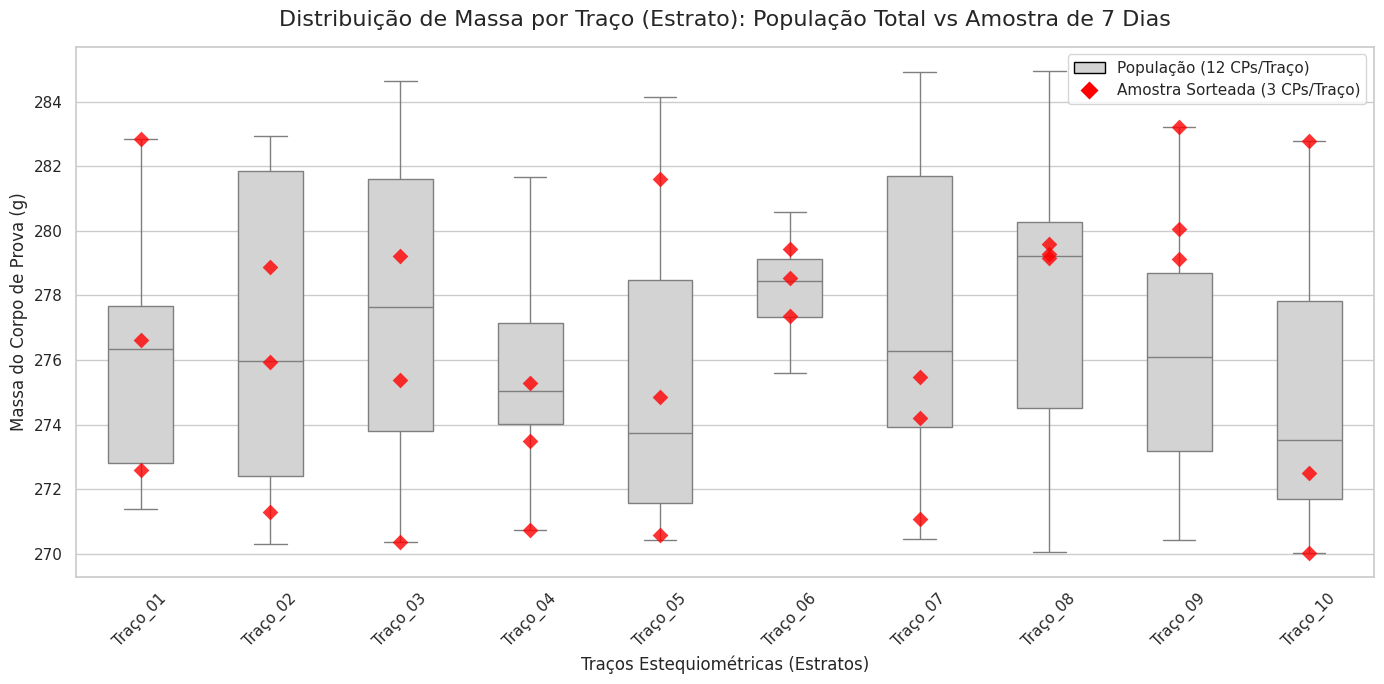

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# 1. PLOT DA POPULAÇÃO TOTAL
# O Boxplot mostra a variação de massa dos 12 CPs dentro de cada um dos 10 traços.
# Ele exibe a mediana, os quartis e os limites de variação de cada estrato.
sns.boxplot(data=df_populacao_csab,
            x='Traco_Estequiometrico',
            y='Massa_g',
            color='lightgray',
            width=0.5,
            showfliers=False)

# 2. PLOT DA AMOSTRA SELECIONADA
# O Stripplot sobrepõe os 3 CPs sorteados de cada traço (30 CPs da amostra).
# Os losangos vermelhos (marker='D') servem para provar visualmente que o sorteio
# retirou representantes de dentro da variação de cada lote.
sns.stripplot(data=df_amostra_7dias,
              x='Traco_Estequiometrico',
              y='Massa_g',
              color='red',
              size=8,
              marker='D',
              jitter=False,
              alpha=0.8)

# 3. TEXTOS, TÍTULOS E AJUSTES VISUAIS
plt.title('Distribuição de Massa por Traço (Estrato): População Total vs Amostra de 7 Dias', fontsize=16, pad=15)
plt.xlabel('Traços Estequiométricas (Estratos)', fontsize=12)
plt.ylabel('Massa do Corpo de Prova (g)', fontsize=12)
plt.xticks(rotation=45) # Inclina os nomes dos traços para não encavalarem

# Criação de uma legenda manual e limpa
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legenda_elementos = [
    Patch(facecolor='lightgray', edgecolor='black', label='População (12 CPs/Traço)'),
    Line2D([0], [0], marker='D', color='w', label='Amostra Sorteada (3 CPs/Traço)', markerfacecolor='red', markersize=10)
]
plt.legend(handles=legenda_elementos, loc='upper right', fontsize=11)

# Ajusta as margens para o gráfico não cortar os textos
plt.tight_layout()

# Exibe a figura
plt.show()

O algoritmo a seguir aplica a Amostragem Aleatória Estratificada sobre as cinzas de eucalipto, estruturado em lotes de coleta com volumes iguais. O objetivo é estabelecer um padrão químico representativo do material para mitigar variações no processo de queima da indústria. Para isso, o código agrupa a população pelos diferentes lotes de origem e realiza a extração de uma quantidade igual de amostras de cada um. Esse método garante que a amostra composta final possua a mesma contribuição de cada período de coleta, permitindo obter uma média química fidedigna que servirá de base sólida e padronizada para os cálculos estequiométricos do clínquer CSAB.

In [6]:
import pandas as pd
import numpy as np

# 1. CONSTRUÇÃO DO BANCO DE DADOS (POPULAÇÃO DA CINZA GLOBAL)
# 3 lotes de coleta distintos
# 10 amostras coletadas rigorosamente em cada ida à indústria (Total: 30 amostras).

origem_lotes = ['Lote_01'] * 10 + ['Lote_02'] * 10 + ['Lote_03'] * 10
dados_cinza_global = {
    'ID_Amostra': [f'Amostra_{i:03d}' for i in range(1, 31)],
    'Lote_Origem': origem_lotes,
    'Massa_kg': np.random.uniform(19.5, 20.5, 30).round(2)
}

df_estoque_cinza = pd.DataFrame(dados_cinza_global)

print("--- Panorama do Estoque de Cinza (Volumes Idênticos por Lote) ---")
print(f"Total de amostras físicas no laboratório: {len(df_estoque_cinza)}")
print(df_estoque_cinza['Lote_Origem'].value_counts())
print("\n")

# 2. APLICAÇÃO DA AMOSTRAGEM ALEATÓRIA ESTRATIFICADA
# Objetivo: Extrair exatamente 3 amostras aleatórias de cada um dos 3 lotes (n=3).
# Isso representa uma robusta taxa de amostragem de 30% por lote.
# A união dessas 9 amostras formará a "Cinza Global" para obter a média química no FRX.

df_amostra_media = df_estoque_cinza.groupby('Lote_Origem').sample(n=3)

--- Panorama do Estoque de Cinza (Volumes Idênticos por Lote) ---
Total de amostras físicas no laboratório: 30
Lote_Origem
Lote_01    10
Lote_02    10
Lote_03    10
Name: count, dtype: int64




In [7]:
# 3. VALIDAÇÃO DA AMOSTRAGEM ESTRATIFICADA
print("--- Validação da Composição da Amostra para FRX (Média Padrão) ---")
# A contagem comprova a equidade: exatamente 3 amostras de cada lote temporal.
print(df_amostra_media['Lote_Origem'].value_counts())
print("\n")

--- Validação da Composição da Amostra para FRX (Média Padrão) ---
Lote_Origem
Lote_01    3
Lote_02    3
Lote_03    3
Name: count, dtype: int64




In [8]:
# 4. EXIBIÇÃO DO SUBCONJUNTO AMOSTRAL
print("--- Unidades Selecionadas para Homogeneização e Ensaio Químico ---")
df_amostra_media

--- Unidades Selecionadas para Homogeneização e Ensaio Químico ---


,ID_Amostra,Lote_Origem,Massa_kg
3,Amostra_004,Lote_01,20.22
8,Amostra_009,Lote_01,19.99
5,Amostra_006,Lote_01,20.01
17,Amostra_018,Lote_02,19.77
16,Amostra_017,Lote_02,20.25
18,Amostra_019,Lote_02,20.12
24,Amostra_025,Lote_03,19.57
22,Amostra_023,Lote_03,20.24
25,Amostra_026,Lote_03,20.32


HISTOGRAMA

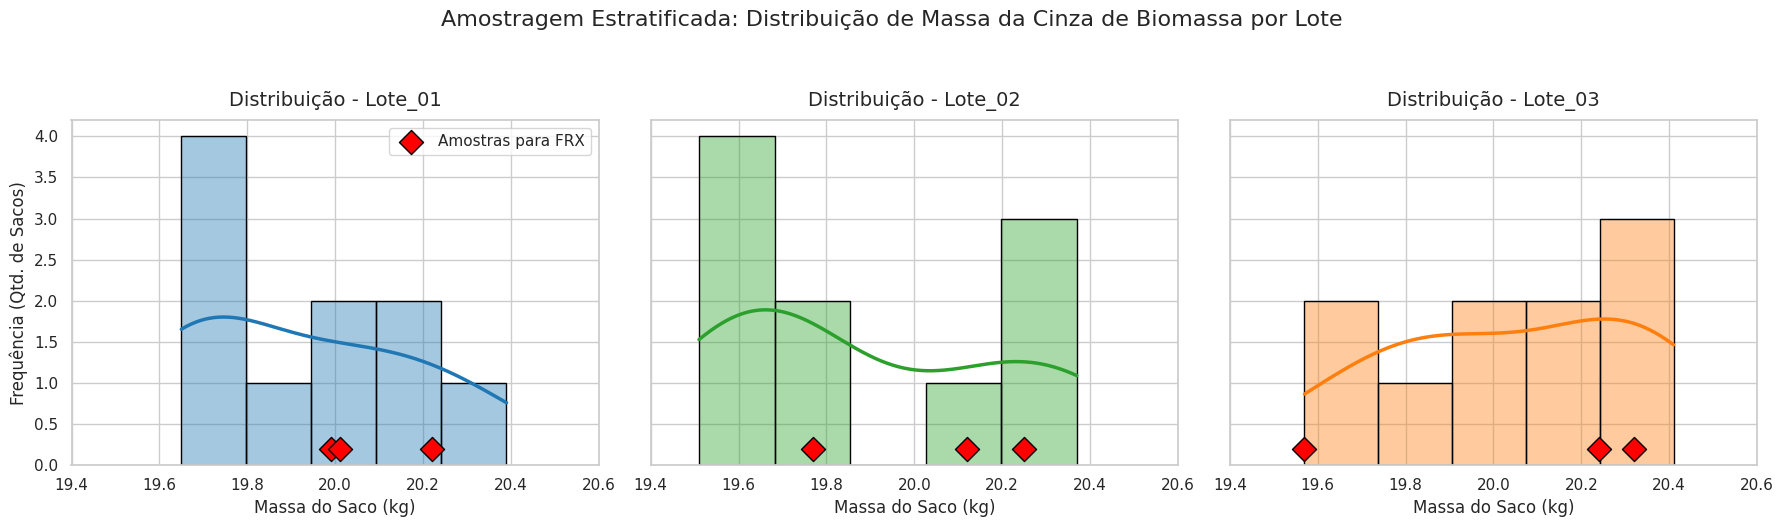

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

lotes = ['Lote_01', 'Lote_02', 'Lote_03']
cores_lotes = ['#1f77b4', '#2ca02c', '#ff7f0e'] # Azul, Verde e Laranja para diferenciar

for i, lote in enumerate(lotes):
    # Filtrando a população e a amostra de cada lote específico
    dados_pop_lote = df_estoque_cinza[df_estoque_cinza['Lote_Origem'] == lote]
    dados_amostra_lote = df_amostra_media[df_amostra_media['Lote_Origem'] == lote]

    # 1. PLOT DO HISTOGRAMA COM LINHA DE TENDÊNCIA (KDE)
    # O parâmetro 'kde=True' é o que gera a curva suave sobre as barras
    sns.histplot(data=dados_pop_lote, x='Massa_kg', bins=5, ax=axes[i],
                 color=cores_lotes[i], kde=True, alpha=0.4,
                 edgecolor='black', line_kws={'linewidth': 2.5})

    # 2. PLOT DAS AMOSTRAS SORTEADAS (Os 3 sacos)
    # Losangos vermelhos na base do gráfico para destacar
    axes[i].scatter(dados_amostra_lote['Massa_kg'],
                    [0.2, 0.2, 0.2], # Altura dos marcadores vermelhos
                    color='red', s=150, marker='D', zorder=10,
                    edgecolor='black', label='Amostras para FRX')

    # 3. TEXTOS E FORMATAÇÕES DE CADA LOTE
    axes[i].set_title(f'Distribuição - {lote}', fontsize=14, pad=10)
    axes[i].set_xlabel('Massa do Saco (kg)', fontsize=12)
    axes[i].set_xlim(19.4, 20.6) # Congela o eixo X para a comparação ser justa

    # Adiciona legenda e eixo Y apenas no primeiro gráfico para ficar limpo
    if i == 0:
        axes[i].set_ylabel('Frequência (Qtd. de Sacos)', fontsize=12)
        axes[i].legend(loc='upper right')

# Título principal do conjunto da obra
plt.suptitle('Amostragem Estratificada: Distribuição de Massa da Cinza de Biomassa por Lote', fontsize=16, y=1.05)

# Ajusta as margens perfeitamente
plt.tight_layout()

# Exibe o gráfico
plt.show()